In [1]:
import pandas as pd, glob, os, csv

ball_files = [f for f in glob.glob("data/ipl_csv2/*.csv") if not f.endswith("_info.csv")]
balls = pd.concat((pd.read_csv(f) for f in ball_files), ignore_index=True)

print(len(ball_files), balls.shape)
print(balls.columns.tolist())
balls.head()

/var/folders/s_/pqgrt59d55z3rwgtwp2vbtk80000gn/T/ipykernel_2767/1579619488.py:4: DtypeWarning: Columns (1,19,26) have mixed types. Specify dtype option on import or set low_memory=False.
  balls = pd.concat((pd.read_csv(f) for f in ball_files), ignore_index=True)


1244 (591464, 27)
['match_id', 'season', 'start_date', 'venue', 'innings', 'ball', 'actual_delivery', 'batting_team', 'bowling_team', 'striker', 'non_striker', 'bowler', 'runs_off_bat', 'extras', 'wides', 'noballs', 'byes', 'legbyes', 'penalty', 'non_boundary', 'wicket_type', 'player_dismissed', 'other_wicket_type', 'other_player_dismissed', 'fielder_1', 'fielder_2', 'fielder_3']


,match_id,season,start_date,venue,innings,ball,actual_delivery,batting_team,bowling_team,striker,...,legbyes,penalty,non_boundary,wicket_type,player_dismissed,other_wicket_type,other_player_dismissed,fielder_1,fielder_2,fielder_3
0,598068,2013,2013-05-18,M Chinnaswamy Stadium,1,0.1,0.1,Royal Challengers Bangalore,Chennai Super Kings,V Kohli,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,598068,2013,2013-05-18,M Chinnaswamy Stadium,1,0.2,0.2,Royal Challengers Bangalore,Chennai Super Kings,V Kohli,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,598068,2013,2013-05-18,M Chinnaswamy Stadium,1,0.3,0.3,Royal Challengers Bangalore,Chennai Super Kings,V Kohli,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,598068,2013,2013-05-18,M Chinnaswamy Stadium,1,0.4,0.4,Royal Challengers Bangalore,Chennai Super Kings,V Kohli,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,598068,2013,2013-05-18,M Chinnaswamy Stadium,1,0.5,0.5,Royal Challengers Bangalore,Chennai Super Kings,CH Gayle,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [2]:
rows = []
for f in glob.glob("data/ipl_csv2/*_info.csv"):
    match = {"match_id": int(os.path.basename(f).split("_")[0])}
    teams = []
    with open(f) as fh:
        for r in csv.reader(fh):
            if len(r) == 3 and r[0] == "info":
                key, value = r[1], r[2]
                if key == "team":
                    teams.append(value)
                elif key not in match:
                    match[key] = value
    match["team1"], match["team2"] = teams[0], teams[1]
    rows.append(match)

matches = pd.DataFrame(rows)
print(matches.shape)
print(matches.columns.tolist())
print(sorted(matches["season"].unique()))

(1243, 28)
['match_id', 'balls_per_over', 'team_type', 'gender', 'season', 'date', 'event', 'match_type', 'overs', 'match_number', 'venue', 'city', 'toss_winner', 'toss_decision', 'player_of_match', 'umpire', 'reserve_umpire', 'tv_umpire', 'match_referee', 'winner', 'winner_wickets', 'team1', 'team2', 'winner_runs', 'super_over', 'outcome', 'eliminator', 'method']
['2007/08', '2009', '2009/10', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020/21', '2021', '2022', '2023', '2024', '2025', '2026']


In [3]:
import sqlite3

# 1. Fix season: use the year the match was actually played
matches["season"] = pd.to_datetime(matches["date"]).dt.year
balls["season"] = pd.to_datetime(balls["start_date"]).dt.year

# 2. Standardise teams that changed names
rename = {
    "Delhi Daredevils": "Delhi Capitals",
    "Kings XI Punjab": "Punjab Kings",
    "Royal Challengers Bangalore": "Royal Challengers Bengaluru",
    "Rising Pune Supergiants": "Rising Pune Supergiant",
}
for col in ["team1", "team2", "toss_winner", "winner"]:
    matches[col] = matches[col].replace(rename)
for col in ["batting_team", "bowling_team"]:
    balls[col] = balls[col].replace(rename)

# 3. Make win margins numeric
for col in ["winner_runs", "winner_wickets"]:
    matches[col] = pd.to_numeric(matches[col], errors="coerce")

# 4. Sanity checks
print(matches["season"].value_counts().sort_index())
print("Ball files without match info:", set(balls["match_id"]) - set(matches["match_id"]))
print(matches["winner"].isna().sum(), "matches with no winner")
print(sorted(set(matches["team1"]) | set(matches["team2"])))

# 5. Save both tables into a SQL database
conn = sqlite3.connect("ipl.db")
matches.to_sql("matches", conn, if_exists="replace", index=False)
balls.to_sql("deliveries", conn, if_exists="replace", index=False)
print("Saved to ipl.db")

season
2008    58
2009    57
2010    60
2011    73
2012    74
2013    76
2014    60
2015    59
2016    60
2017    59
2018    60
2019    60
2020    60
2021    60
2022    74
2023    74
2024    71
2025    74
2026    74
Name: count, dtype: int64
Ball files without match info: set()
25 matches with no winner
['Chennai Super Kings', 'Deccan Chargers', 'Delhi Capitals', 'Gujarat Lions', 'Gujarat Titans', 'Kochi Tuskers Kerala', 'Kolkata Knight Riders', 'Lucknow Super Giants', 'Mumbai Indians', 'Pune Warriors', 'Punjab Kings', 'Rajasthan Royals', 'Rising Pune Supergiant', 'Royal Challengers Bengaluru', 'Sunrisers Hyderabad']
Saved to ipl.db


In [4]:
# Find files that aren't single matches
odd = [f for f in ball_files if not os.path.basename(f).split(".")[0].isdigit()]
print("Non-match files:", odd)

# Rebuild balls using only per-match files (names that are just numbers)
ball_files = [f for f in ball_files if os.path.basename(f).split(".")[0].isdigit()]
balls = pd.concat((pd.read_csv(f, low_memory=False) for f in ball_files), ignore_index=True)

# Re-apply the cleaning
balls["season"] = pd.to_datetime(balls["start_date"]).dt.year
for col in ["batting_team", "bowling_team"]:
    balls[col] = balls[col].replace(rename)

print(len(ball_files), "files |", balls.shape, "| balls per match:", round(len(balls) / balls["match_id"].nunique()))

# Save again
balls.to_sql("deliveries", conn, if_exists="replace", index=False)
print("Saved")

Non-match files: ['data/ipl_csv2/all_matches.csv']
1243 files | (295732, 27) | balls per match: 238
Saved


In [5]:
def q(sql):
    return pd.read_sql(sql, conn)

In [6]:
q("""
WITH played AS (
  SELECT team1 AS team, winner FROM matches WHERE winner IS NOT NULL
  UNION ALL
  SELECT team2, winner FROM matches WHERE winner IS NOT NULL
)
SELECT team, COUNT(*) AS played,
       SUM(team = winner) AS won,
       ROUND(100.0 * SUM(team = winner) / COUNT(*), 1) AS win_pct
FROM played
GROUP BY team HAVING played >= 50
ORDER BY win_pct DESC
""")

,team,played,won,win_pct
0,Gujarat Titans,77,47,61.0
1,Chennai Super Kings,264,148,56.1
2,Mumbai Indians,287,155,54.0
3,Kolkata Knight Riders,271,140,51.7
4,Royal Challengers Bengaluru,280,143,51.1
5,Rajasthan Royals,245,123,50.2
6,Sunrisers Hyderabad,206,102,49.5
7,Lucknow Super Giants,70,34,48.6
8,Punjab Kings,271,126,46.5
9,Delhi Capitals,272,125,46.0


In [7]:
rr = q("""
SELECT season,
  CASE WHEN CAST(ball AS INT) < 6  THEN '1 Powerplay'
       WHEN CAST(ball AS INT) < 15 THEN '2 Middle'
       ELSE '3 Death' END AS phase,
  ROUND(6.0 * SUM(runs_off_bat + extras) /
        SUM(CASE WHEN COALESCE(wides,0)=0 AND COALESCE(noballs,0)=0 THEN 1 ELSE 0 END), 2) AS run_rate
FROM deliveries
WHERE innings <= 2
GROUP BY season, phase
""")
rr.pivot(index="season", columns="phase", values="run_rate")

phase,1 Powerplay,2 Middle,3 Death
season,,,
2008,7.70,7.99,9.95
2009,7.22,6.85,9.13
2010,7.89,7.56,9.59
2011,7.20,7.44,9.11
2012,7.22,7.40,9.52
2013,6.93,7.24,9.57
2014,7.55,7.74,10.04
2015,7.76,7.84,10.31
2016,7.70,7.86,10.17


In [8]:
q("""
WITH totals AS (
  SELECT match_id, season, SUM(runs_off_bat + extras) AS total
  FROM deliveries WHERE innings = 1
  GROUP BY match_id, season
)
SELECT season, COUNT(*) AS matches, ROUND(AVG(total), 1) AS avg_first_innings
FROM totals GROUP BY season ORDER BY season
""")

,season,matches,avg_first_innings
0,2008,58,161.0
1,2009,57,150.3
2,2010,60,164.8
3,2011,73,152.4
4,2012,74,157.5
5,2013,76,155.9
6,2014,60,163.1
7,2015,59,166.3
8,2016,60,162.6
9,2017,59,165.8


In [9]:
q("""
WITH b AS (
  SELECT striker, SUM(runs_off_bat) AS runs,
         SUM(CASE WHEN COALESCE(wides,0)=0 THEN 1 ELSE 0 END) AS balls_faced
  FROM deliveries
  WHERE CAST(ball AS INT) >= 15 AND season >= 2023
  GROUP BY striker HAVING balls_faced >= 100
)
SELECT striker, runs, balls_faced,
       ROUND(100.0 * runs / balls_faced, 1) AS strike_rate,
       RANK() OVER (ORDER BY 1.0 * runs / balls_faced DESC) AS sr_rank
FROM b ORDER BY sr_rank LIMIT 10
""")

,striker,runs,balls_faced,strike_rate,sr_rank
0,MP Stoinis,399,179,222.9,1
1,LS Livingstone,235,107,219.6,2
2,SS Iyer,444,206,215.5,3
3,B Sai Sudharsan,276,131,210.7,4
4,RR Pant,305,145,210.3,5
5,Tilak Varma,445,212,209.9,6
6,SA Yadav,286,141,202.8,7
7,RM Patidar,215,106,202.8,8
8,Shashank Singh,465,230,202.2,9
9,T Stubbs,544,273,199.3,10


In [10]:
%pip install scipy -q

You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [11]:
from scipy import stats

fi = q("""
SELECT d.match_id, d.season, SUM(d.runs_off_bat + d.extras) AS total
FROM deliveries d JOIN matches m ON d.match_id = m.match_id
WHERE d.innings = 1 AND m.method IS NULL
GROUP BY d.match_id, d.season
""")

before = fi[fi.season.between(2019, 2022)]["total"]
after  = fi[fi.season.between(2023, 2026)]["total"]

t, p = stats.ttest_ind(after, before, equal_var=False)
print(f"Before (2019-22): n={len(before)}, mean={before.mean():.1f}")
print(f"After  (2023-26): n={len(after)}, mean={after.mean():.1f}")
print(f"Difference: {after.mean() - before.mean():.1f} runs | t={t:.2f} | p={p:.2e}")

# Placebo check: was there a similar jump between two earlier 4-year blocks?
early, late = fi[fi.season.between(2015, 2018)]["total"], fi[fi.season.between(2019, 2022)]["total"]
pp = stats.ttest_ind(late, early, equal_var=False).pvalue
print(f"Placebo 2015-18 -> 2019-22: {early.mean():.1f} -> {late.mean():.1f} | p={pp:.3f}")

Before (2019-22): n=254, mean=166.9
After  (2023-26): n=289, mean=188.5
Difference: 21.6 runs | t=7.38 | p=6.18e-13
Placebo 2015-18 -> 2019-22: 167.4 -> 166.9 | p=0.865


In [12]:
%pip install matplotlib -q

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


Matplotlib is building the font cache; this may take a moment.


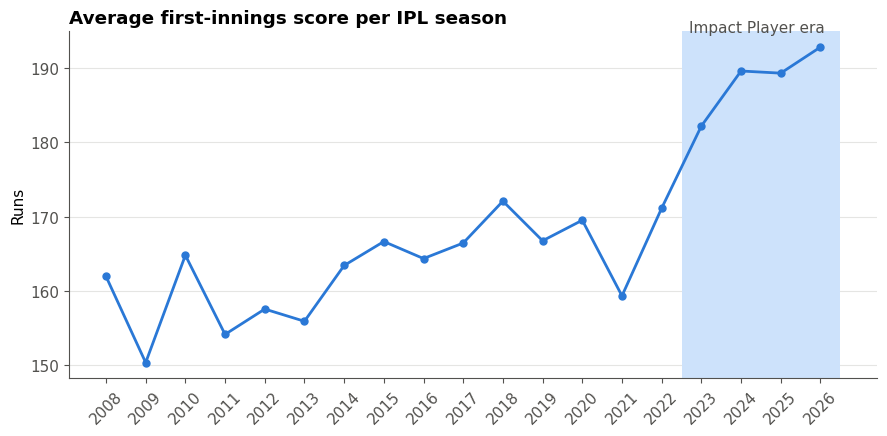

In [13]:
import matplotlib.pyplot as plt, os
os.makedirs("charts", exist_ok=True)
plt.rcParams.update({"font.size": 11, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.edgecolor": "#52514e", "xtick.color": "#52514e", "ytick.color": "#52514e"})

s = fi.groupby("season")["total"].mean()
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.axvspan(2022.5, 2026.5, color="#cde2fb", lw=0)
ax.plot(s.index, s.values, color="#2a78d6", lw=2, marker="o", ms=5)
ax.text(2022.7, s.max() + 2, "Impact Player era", color="#52514e")
ax.set_title("Average first-innings score per IPL season", loc="left", fontweight="bold")
ax.set_ylabel("Runs")
ax.set_xticks(s.index); ax.tick_params(axis="x", rotation=45)
ax.grid(axis="y", color="#e5e5e3"); ax.set_axisbelow(True)
plt.tight_layout(); plt.savefig("charts/first_innings_by_season.png", dpi=200); plt.show()

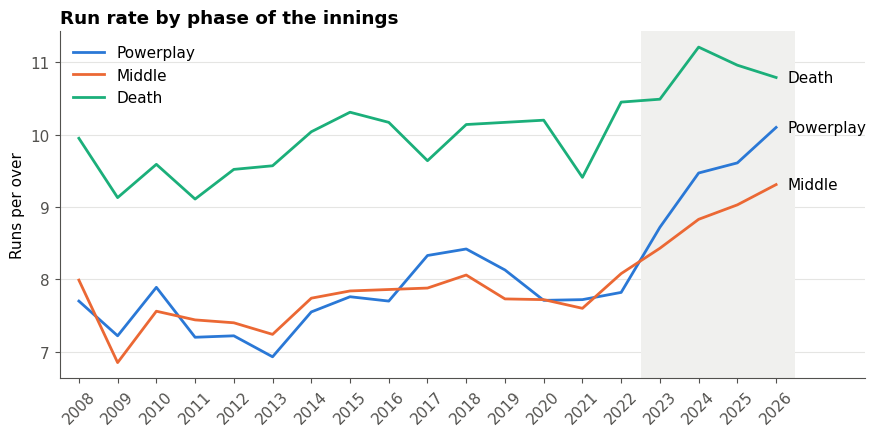

In [14]:
pv = rr.pivot(index="season", columns="phase", values="run_rate")
colors = {"1 Powerplay": "#2a78d6", "2 Middle": "#eb6834", "3 Death": "#1baf7a"}

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.axvspan(2022.5, 2026.5, color="#f0f0ee", lw=0)
for phase, c in colors.items():
    ax.plot(pv.index, pv[phase], color=c, lw=2, label=phase[2:])
    ax.text(pv.index[-1] + 0.3, pv[phase].iloc[-1], phase[2:], va="center")
ax.set_title("Run rate by phase of the innings", loc="left", fontweight="bold")
ax.set_ylabel("Runs per over")
ax.set_xticks(pv.index); ax.tick_params(axis="x", rotation=45)
ax.set_xlim(2007.5, 2028.3)
ax.legend(frameon=False, loc="upper left")
ax.grid(axis="y", color="#e5e5e3"); ax.set_axisbelow(True)
plt.tight_layout(); plt.savefig("charts/run_rate_by_phase.png", dpi=200); plt.show()

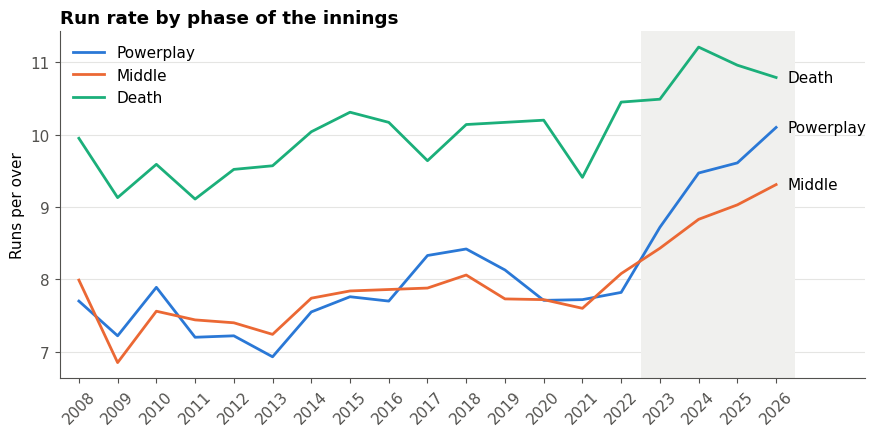

In [15]:
pv = rr.pivot(index="season", columns="phase", values="run_rate")
colors = {"1 Powerplay": "#2a78d6", "2 Middle": "#eb6834", "3 Death": "#1baf7a"}

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.axvspan(2022.5, 2026.5, color="#f0f0ee", lw=0)
for phase, c in colors.items():
    ax.plot(pv.index, pv[phase], color=c, lw=2, label=phase[2:])
    ax.text(pv.index[-1] + 0.3, pv[phase].iloc[-1], phase[2:], va="center")
ax.set_title("Run rate by phase of the innings", loc="left", fontweight="bold")
ax.set_ylabel("Runs per over")
ax.set_xticks(pv.index); ax.tick_params(axis="x", rotation=45)
ax.set_xlim(2007.5, 2028.3)
ax.legend(frameon=False, loc="upper left")
ax.grid(axis="y", color="#e5e5e3"); ax.set_axisbelow(True)
plt.tight_layout(); plt.savefig("charts/run_rate_by_phase.png", dpi=200); plt.show()

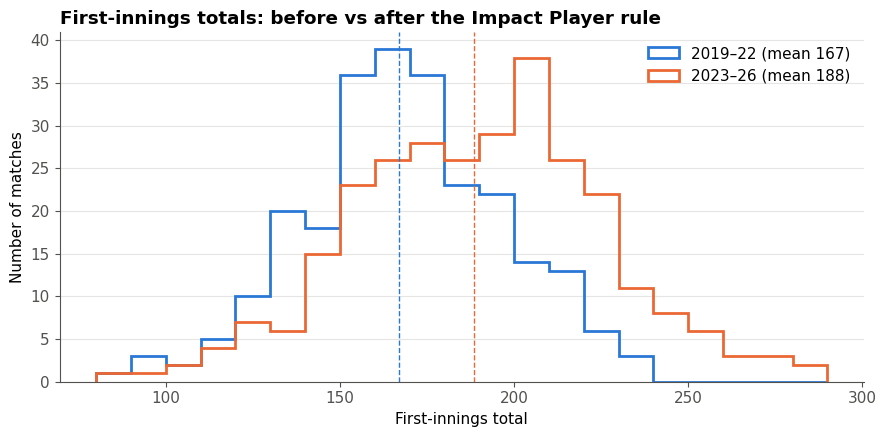

In [16]:
fig, ax = plt.subplots(figsize=(9, 4.5))
bins = range(80, 300, 10)
ax.hist(before, bins=bins, histtype="step", lw=2, color="#2a78d6", label=f"2019–22 (mean {before.mean():.0f})")
ax.hist(after,  bins=bins, histtype="step", lw=2, color="#eb6834", label=f"2023–26 (mean {after.mean():.0f})")
ax.axvline(before.mean(), color="#2a78d6", ls="--", lw=1)
ax.axvline(after.mean(),  color="#eb6834", ls="--", lw=1)
ax.set_title("First-innings totals: before vs after the Impact Player rule", loc="left", fontweight="bold")
ax.set_xlabel("First-innings total"); ax.set_ylabel("Number of matches")
ax.legend(frameon=False)
ax.grid(axis="y", color="#e5e5e3"); ax.set_axisbelow(True)
plt.tight_layout(); plt.savefig("charts/before_after_distribution.png", dpi=200); plt.show()

In [17]:
eng = q("""
WITH b AS (
  SELECT season,
         ROUND(1.0 * SUM(runs_off_bat IN (4, 6)) / COUNT(DISTINCT match_id), 1) AS boundaries_per_match,
         ROUND(1.0 * SUM(runs_off_bat = 6) / COUNT(DISTINCT match_id), 1)       AS sixes_per_match
  FROM deliveries WHERE innings <= 2
  GROUP BY season
),
last_over AS (
  SELECT match_id, MAX(CAST(ball AS INT)) AS lo
  FROM deliveries WHERE innings = 2 GROUP BY match_id
),
c AS (
  SELECT m.season,
         ROUND(100.0 * AVG(CASE WHEN m.winner_runs <= 10
                                  OR (m.winner_wickets IS NOT NULL AND l.lo >= 19)
                                THEN 1 ELSE 0 END), 1) AS close_finish_pct
  FROM matches m JOIN last_over l ON m.match_id = l.match_id
  WHERE m.winner IS NOT NULL AND m.method IS NULL
  GROUP BY m.season
)
SELECT b.*, c.close_finish_pct
FROM b JOIN c ON b.season = c.season
ORDER BY b.season
""")
eng

,season,boundaries_per_match,sixes_per_match,close_finish_pct
0,2008,40.1,10.7,32.1
1,2009,32.0,8.9,37.7
2,2010,38.2,9.8,25.4
3,2011,35.0,8.8,21.7
4,2012,35.7,9.9,35.1
5,2013,35.9,8.9,29.7
6,2014,37.9,11.9,31.0
7,2015,39.0,11.7,33.3
8,2016,37.9,10.7,35.7
9,2017,39.3,11.9,31.6


In [18]:
from scipy.stats import chi2_contingency

cf = q("""
WITH last_over AS (
  SELECT match_id, MAX(CAST(ball AS INT)) AS lo
  FROM deliveries WHERE innings = 2 GROUP BY match_id
)
SELECT m.season,
       CASE WHEN m.winner_runs <= 10 OR (m.winner_wickets IS NOT NULL AND l.lo >= 19)
            THEN 1 ELSE 0 END AS close
FROM matches m JOIN last_over l ON m.match_id = l.match_id
WHERE m.winner IS NOT NULL AND m.method IS NULL
""")
cf["era"] = cf["season"].apply(lambda s: "after" if s >= 2023 else ("before" if s >= 2019 else None))
cf = cf.dropna(subset=["era"])

table = pd.crosstab(cf["era"], cf["close"])
chi2, p, _, _ = chi2_contingency(table)
print(table)
print(cf.groupby("era")["close"].mean().round(3))
print(f"p = {p:.3f}")

close     0   1
era            
after   200  82
before  160  86
era
after     0.291
before    0.350
Name: close, dtype: float64
p = 0.176
